# 01 · Exploratory Data Analysis

**Goal:** Understand the dataset structure, class balance, text length distributions,
and key properties before modelling.

**Sections:**
1. Load & validate data
2. Split / label / group statistics
3. Text length distributions
4. Per-content-type breakdown (T1–T6)
5. Per-source / per-model breakdown
6. Vocabulary & lexical diversity quick look
7. Save summary tables for the thesis

**Notes:**
- This notebook is designed for the thesis dataset with Human vs LLM labels.
- It supports multiple input formats: `train/val/test.parquet`, `dataset.parquet`,
  or `train/val/test.csv`.
- Figures are saved to `outputs/figures/eda/`, tables to `outputs/tables/`.


In [1]:
# ── 0. Imports & settings ────────────────────────────────────────────────

import json
import pathlib
import re
import warnings
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.bbox"] = "tight"


def resolve_project_root() -> pathlib.Path:
    """Try a few common layouts to find the project root."""
    cwd = pathlib.Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]

    for c in candidates:
        if (c / "data" / "final").exists():
            return c

    # fallback: assume notebook is in notebooks/
    return cwd.parent


PROJECT_ROOT = resolve_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "final"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "figures" / "eda"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"TABLE_DIR    : {TABLE_DIR}")
print(f"Files found  : {sorted(p.name for p in DATA_DIR.iterdir()) if DATA_DIR.exists() else 'DIR NOT FOUND'}")


PROJECT_ROOT : /Users/askar/projects/antifraud-deepfake-detection
DATA_DIR     : /Users/askar/projects/antifraud-deepfake-detection/data/final
OUTPUT_DIR   : /Users/askar/projects/antifraud-deepfake-detection/outputs/figures/eda
TABLE_DIR    : /Users/askar/projects/antifraud-deepfake-detection/outputs/tables
Files found  : ['dataset_stats.json', 'test.jsonl', 'train.jsonl', 'val.jsonl']


## 1 · Load & validate data

In [5]:
def load_dataset(data_dir: pathlib.Path) -> pd.DataFrame:
    data_dir = pathlib.Path(data_dir)

    split_files = {s: data_dir / f"{s}.jsonl" for s in ["train", "val", "test"]}
    if all(f.exists() for f in split_files.values()):
        frames = []
        for split_name, fpath in split_files.items():
            # Specify lines=True and orient="records" for jsonl loading
            tmp = pd.read_json(fpath, lines=True, orient="records")
            if "split" not in tmp.columns:
                tmp["split"] = split_name
            frames.append(tmp)
        df = pd.concat(frames, ignore_index=True)
        print(f"Loaded 3 jsonl splits → {len(df):,} rows")
        return df


df = load_dataset(DATA_DIR)
display(df.head(3))


Loaded 3 jsonl splits → 18,993 rows


,text,label,label_str,origin_model,content_type,dataset_source,char_length,split,text_clean,lang,lang_score,length_bin,temperature_style,temperature_value,generation_type,theme,sample_id,_companion
0,Cholera and typhus are both infectious disease...,1,llm,chatgpt,legitimate,hc3_open_qa,1320,train,Cholera and typhus are both infectious disease...,en,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"In the context of cryptocurrency, a ""mule"" ref...",1,llm,chatgpt,legitimate,hc3_open_qa,1081,train,"In the context of cryptocurrency, a ""mule"" ref...",en,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"Dear,regret i cudnt pick call.drove down frm c...",0,human,None,legitimate,sms_spam_uci,124,train,"Dear,regret i cudnt pick call.drove down frm c...",en,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Shape:", df.shape)
print("\nColumns:")
print(list(df.columns))
print("\nDtypes:")
print(df.dtypes)
print("\nNull counts:")
print(df.isnull().sum().sort_values(ascending=False))

if "text" in df.columns:
    print("\nDuplicate texts:", int(df["text"].duplicated().sum()))
else:
    print("\nColumn 'text' not found yet.")


Shape: (18993, 18)

Columns:
['text', 'label', 'label_str', 'origin_model', 'content_type', 'dataset_source', 'char_length', 'split', 'text_clean', 'lang', 'lang_score', 'length_bin', 'temperature_style', 'temperature_value', 'generation_type', 'theme', 'sample_id', '_companion']

Dtypes:
text                  object
label                  int64
label_str             object
origin_model          object
content_type          object
dataset_source        object
char_length            int64
split                 object
text_clean            object
lang                  object
lang_score           float64
length_bin            object
temperature_style     object
temperature_value    float64
generation_type       object
theme                 object
sample_id            float64
_companion           float64
dtype: object

Null counts:
_companion           15898
sample_id            12419
theme                12419
generation_type      12419
temperature_value    12419
temperature_style    1241

In [8]:
REQUIRED = ["text", "label", "split"]
for col in REQUIRED:
    if col not in df.columns:
        raise AssertionError(f"Missing required column: {col}")

df = df.copy()
df["text"] = df["text"].fillna("").astype(str)
df["split"] = df["split"].astype(str).str.lower()

# Label semantics
LABEL_MAP = {0: "Human", 1: "LLM"}
df["label_str"] = df["label"].map(LABEL_MAP).fillna("Unknown")

# Text length features
df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()
df["n_sentences"] = df["text"].str.count(r"[.!?]+")

# Group column (A/B/C/D) — derive if missing (docs/dataset_contract.md factorial design)
# Map content_type → fraudulent vs legitimate, aligned with src/generation/generate.py:
#   T1–T4 → llm_fraud; T5–T6 → llm_legit; human corpora use the same string labels.
CONTENT_TYPE_FRAUDULENT = frozenset(
    {
        "phishing",  # T1
        "smishing",  # T2
        "social_engineering",  # T3
        "scam_419",  # T4
        "spam",  # Enron / SpamAssassin spam
    }
)
CONTENT_TYPE_LEGITIMATE = frozenset(
    {
        "legitimate",  # ham (SMS, Enron, SpamAssassin, HC3)
        "bank_notification",  # T5
        "financial_review",  # T6
        "financial_qa",  # HC3 finance Q&A
        "review",  # Yelp (financial review–style)
    }
)

if "group" not in df.columns:
    if "is_fraud" in df.columns:
        conditions = [
            (df["label"] == 0) & (df["is_fraud"] == 1),
            (df["label"] == 0) & (df["is_fraud"] == 0),
            (df["label"] == 1) & (df["is_fraud"] == 1),
            (df["label"] == 1) & (df["is_fraud"] == 0),
        ]
        df["group"] = np.select(conditions, ["A", "B", "C", "D"], default="?")
    elif "content_type" in df.columns:
        ct = df["content_type"].fillna("").astype(str).str.strip()
        legit = pd.Series(np.nan, index=df.index, dtype=float)
        legit.loc[ct.isin(CONTENT_TYPE_LEGITIMATE)] = 1.0
        legit.loc[ct.isin(CONTENT_TYPE_FRAUDULENT)] = 0.0
        n_unknown = int(legit.isna().sum())
        if n_unknown:
            print(
                f"⚠️ {n_unknown} rows have content_type outside known "
                "legitimate/fraudulent sets — group set to '?' for those rows."
            )
        conditions = [
            (df["label"] == 0) & (legit == 0),
            (df["label"] == 0) & (legit == 1),
            (df["label"] == 1) & (legit == 0),
            (df["label"] == 1) & (legit == 1),
        ]
        df["group"] = np.select(conditions, ["A", "B", "C", "D"], default="?")
    else:
        print(
            "⚠️ Cannot derive 'group': need column 'content_type' or 'is_fraud'. "
            "Group-level analysis will be skipped."
        )

print("Derived columns added. Shape:", df.shape)
display(df[[c for c in ["split", "label", "label_str", "n_chars", "n_words", "n_sentences", "group"] if c in df.columns]].head())


Derived columns added. Shape: (18993, 22)


,split,label,label_str,n_chars,n_words,n_sentences,group
0,train,1,LLM,1320,205,10,D
1,train,1,LLM,1081,176,6,D
2,train,0,Human,124,18,5,B
3,train,1,LLM,884,138,10,D
4,train,0,Human,4059,421,34,A


## 2 · Split / label / group statistics

In [9]:
split_order = ["train", "val", "test"]
available_splits = [s for s in split_order if s in set(df["split"].unique())]

# ── 2a. Samples per split × label ──
ct_split_label = (
    pd.crosstab(df["split"], df["label_str"], margins=True)
    .reindex(index=available_splits + ["All"])
)
display(ct_split_label)


label_str,Human,LLM,All
split,,,
train,5329,5329,10658
val,866,866,1732
test,3562,3041,6603
All,9757,9236,18993


In [10]:
# ── 2b. Class balance ratio per split ──
balance = (
    df.groupby("split")["label"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns=LABEL_MAP)
    .reindex(available_splits)
)
display(balance.style.format("{:.2%}"))


label,Human,LLM
split,,
train,50.00%,50.00%
val,50.00%,50.00%
test,53.95%,46.05%


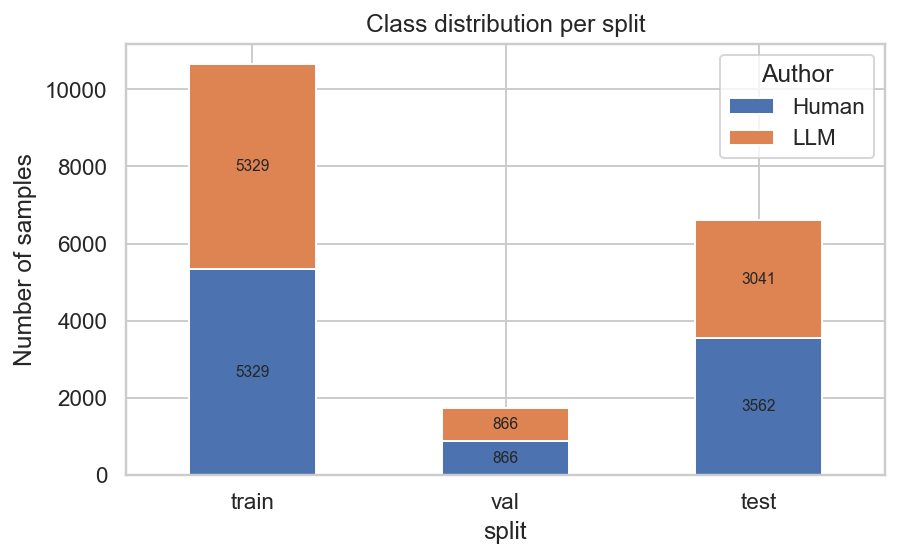

In [11]:
# ── 2c. Stacked bar: split × label ──
fig, ax = plt.subplots(figsize=(7, 4))
ct_no_margin = ct_split_label.drop(index="All", errors="ignore").drop(columns="All", errors="ignore")
ct_no_margin.plot.bar(stacked=True, ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("Number of samples")
ax.set_title("Class distribution per split")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Author")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", label_type="center", fontsize=8)
fig.savefig(OUTPUT_DIR / "split_label_distribution.png")
plt.show()


,A · Human Fraud,B · Human Legit,C · LLM Fraud,D · LLM Legit
split,,,,
train,1729,3600,1932,3397
val,281,585,314,552
test,1298,2264,1773,1268


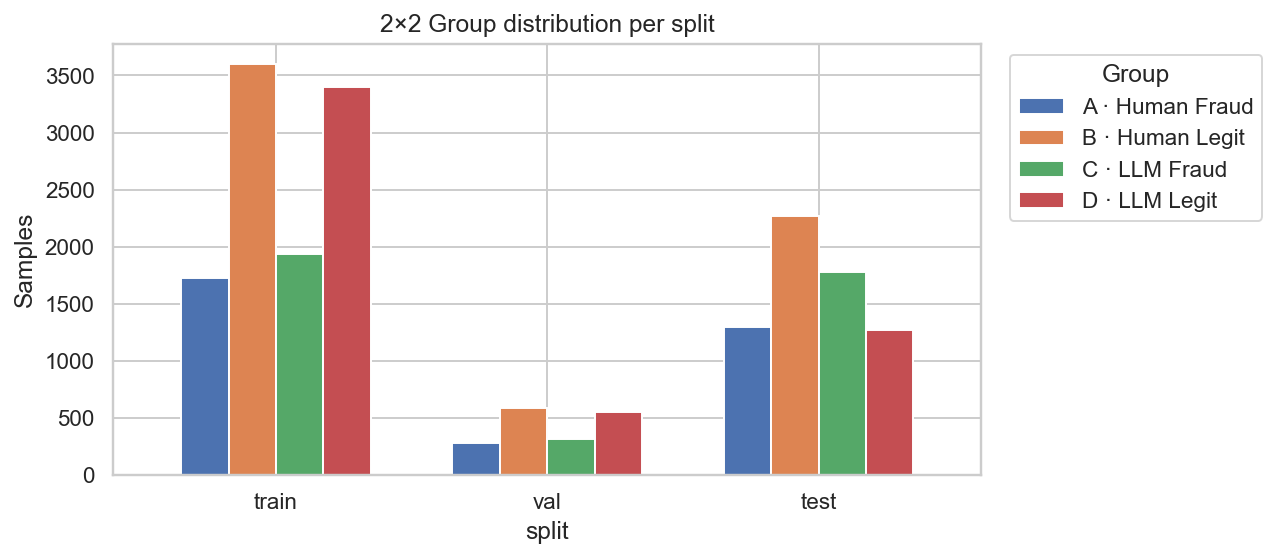

In [12]:
# ── 2d. Group distribution (A/B/C/D) ──
if "group" in df.columns:
    GROUP_LABELS = {
        "A": "A · Human Fraud",
        "B": "B · Human Legit",
        "C": "C · LLM Fraud",
        "D": "D · LLM Legit",
    }
    ct_group = (
        pd.crosstab(df["split"], df["group"])
        .reindex(index=available_splits, columns=["A", "B", "C", "D"])
    )
    ct_group.columns = [GROUP_LABELS.get(c, c) for c in ct_group.columns]
    display(ct_group)

    fig, ax = plt.subplots(figsize=(8, 4))
    ct_group.plot.bar(ax=ax, width=0.7)
    ax.set_ylabel("Samples")
    ax.set_title("2×2 Group distribution per split")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
    fig.savefig(OUTPUT_DIR / "group_distribution.png")
    plt.show()
else:
    print("Group column not available — skipping.")


## 3 · Text length distributions

In [13]:
# ── 3a. Summary statistics ──
length_stats = (
    df.groupby(["split", "label_str"])[["n_chars", "n_words", "n_sentences"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95])
    .round(1)
)
display(length_stats)


n_chars                                                      \
                  count    mean     std   min    25%    50%     75%     95%   
split label_str                                                               
test  Human      3562.0  1275.4  2988.4  50.0  281.0  683.0  1465.8  4067.1   
      LLM        3041.0   618.1   553.8  51.0  187.0  436.0   892.0  1888.0   
train Human      5329.0  1246.1  2849.3  50.0  172.0  616.0  1433.0  4020.2   
      LLM        5329.0   604.0   445.9  53.0  279.0  441.0   844.0  1511.6   
val   Human       866.0  1175.6  2541.4  50.0  178.2  611.0  1432.8  3898.8   
      LLM         866.0   588.8   415.4  71.0  281.2  437.0   851.5  1424.0   

                          n_words  ...          n_sentences                   \
                      max   count  ...      max       count  mean   std  min   
split label_str                    ...                                         
test  Human      142681.0  3562.0  ...  28001.0      3562.0  15.2  36.0  0.0   
      LLM          4723.0  3041.0  ...    676.0      3041.0   8.1   4.5  1.0   
train Human       89425.0  5329.0  ...  14954.0      5329.0  14.6  32.7  0.0   
      LLM          3158.0  5329.0  ...    544.0      5329.0   6.8   3.2  1.0   
val   Human       62588.0   866.0  ...   5273.0       866.0  13.2  24.5  0.0   
      LLM          2112.0   866.0  ...    379.0       866.0   6.6   2.8  2.0   

                                               
                 25%  50%   75%   95%     max  
split label_str                                
test  Human      4.0  8.0  17.0  46.0  1436.0  
      LLM        5.0  7.0  10.0  17.0    43.0  
train Human      3.0  8.0  16.0  42.0  1146.0  
      LLM        5.0  6.0   8.0  13.0    26.0  
val   Human      3.0  8.0  17.0  40.0   562.0  
      LLM        5.0  6.0   8.0  12.0    19.0  

[6 rows x 27 columns]

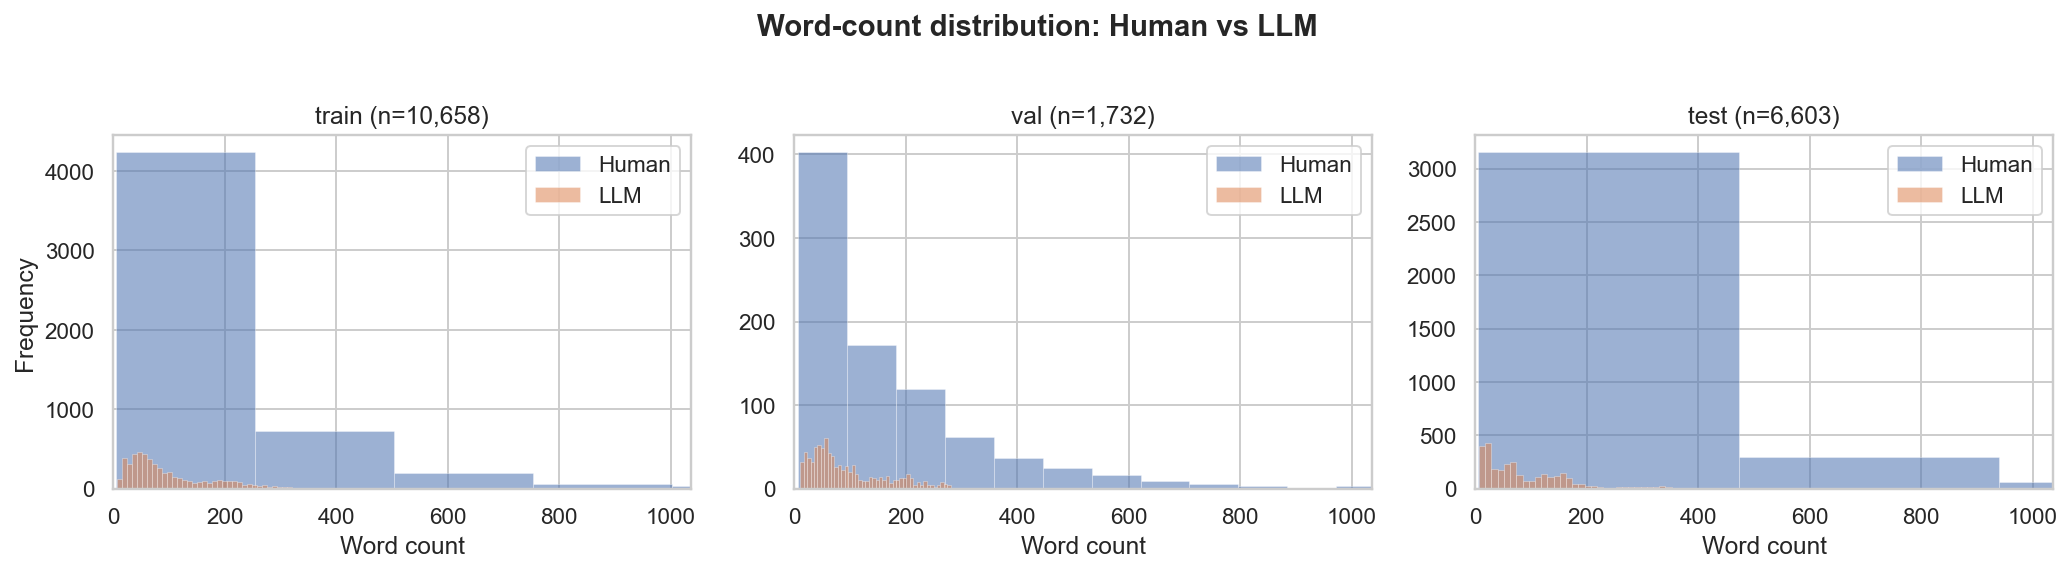

In [14]:
# ── 3b. Word-count histograms: Human vs LLM ──
n_panels = max(1, len(available_splits))
fig, axes = plt.subplots(1, n_panels, figsize=(5 * n_panels, 4), sharey=False)
if n_panels == 1:
    axes = [axes]

xmax = max(10, float(df["n_words"].quantile(0.99)))

for i, split_name in enumerate(available_splits):
    ax = axes[i]
    subset = df[df["split"] == split_name]
    for label_val, color, lbl in [(0, "#4C72B0", "Human"), (1, "#DD8452", "LLM")]:
        data = subset.loc[subset["label"] == label_val, "n_words"]
        if len(data) > 0:
            ax.hist(data, bins=60, alpha=0.55, color=color, label=lbl, edgecolor="white", linewidth=0.3)
    ax.set_title(f"{split_name} (n={len(subset):,})")
    ax.set_xlabel("Word count")
    ax.set_xlim(0, xmax)
    ax.legend()
axes[0].set_ylabel("Frequency")
fig.suptitle("Word-count distribution: Human vs LLM", y=1.02, fontweight="bold")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "word_count_hist.png")
plt.show()


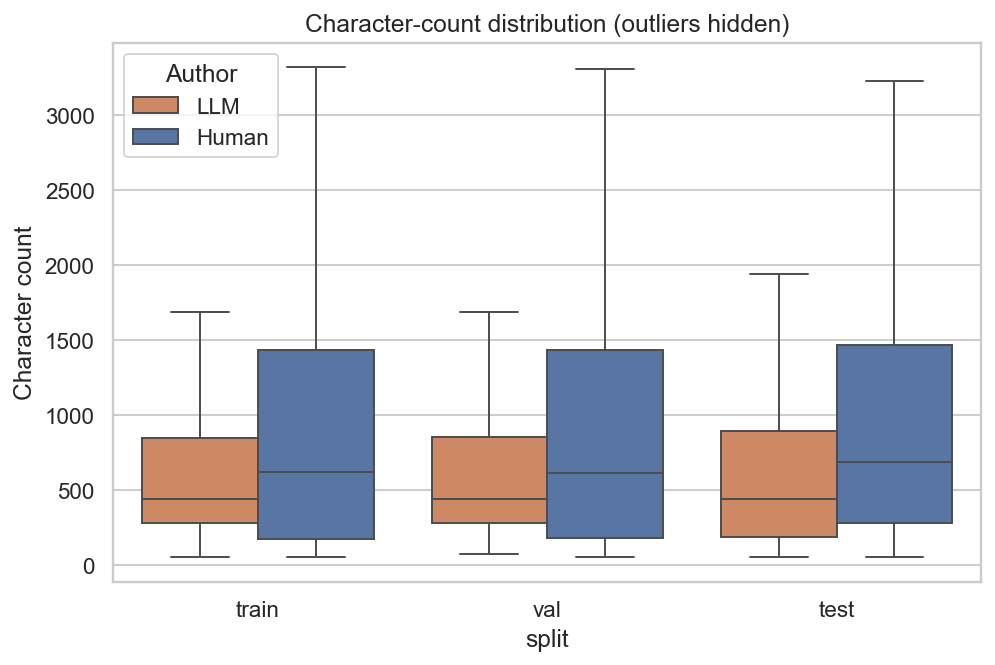

In [15]:
# ── 3c. Box-plots: chars by label × split ──
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="split", y="n_chars", hue="label_str",
    order=available_splits, showfliers=False, ax=ax,
    palette={"Human": "#4C72B0", "LLM": "#DD8452", "Unknown": "#999999"},
)
ax.set_ylabel("Character count")
ax.set_title("Character-count distribution (outliers hidden)")
ax.legend(title="Author")
fig.savefig(OUTPUT_DIR / "char_count_boxplot.png")
plt.show()


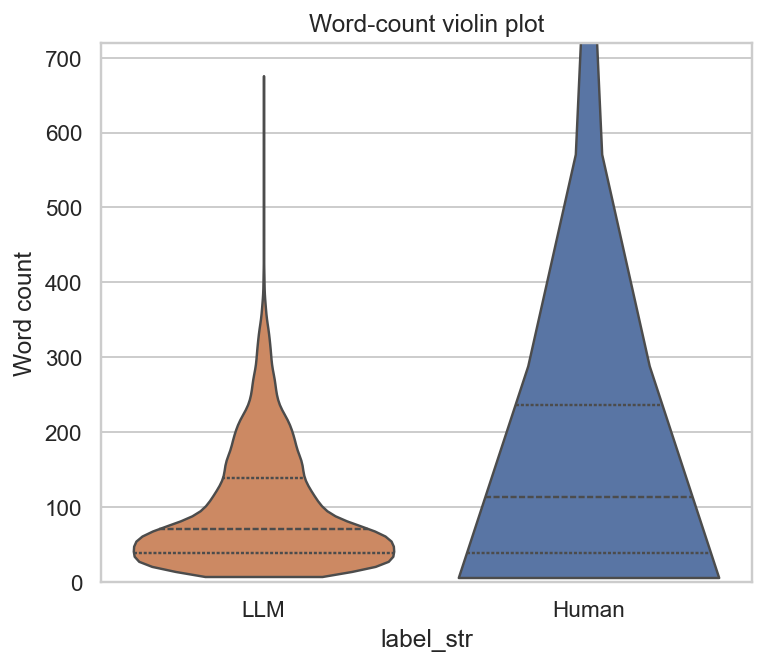

In [16]:
# ── 3d. Violin: words by label (full dataset) ──
fig, ax = plt.subplots(figsize=(6, 5))
sns.violinplot(
    data=df, x="label_str", y="n_words", inner="quartile",
    palette={"Human": "#4C72B0", "LLM": "#DD8452", "Unknown": "#999999"}, cut=0, ax=ax,
)
ax.set_ylabel("Word count")
ax.set_ylim(0, max(10, float(df["n_words"].quantile(0.98))))
ax.set_title("Word-count violin plot")
fig.savefig(OUTPUT_DIR / "word_count_violin.png")
plt.show()


## 4 · Per-content-type breakdown (T1–T6)

In [17]:
# ── Detect content-type column ──
CT_COL: Optional[str] = None
for candidate in ["content_type", "type", "category", "content_type_id"]:
    if candidate in df.columns:
        CT_COL = candidate
        break

if CT_COL:
    print(f"Content-type column found: '{CT_COL}'")
    display(df[CT_COL].value_counts(dropna=False).sort_index())
else:
    print("⚠️ No content-type column found. Section 4 will be limited.")


Content-type column found: 'content_type'


content_type
bank_notification     1388
financial_qa          1975
financial_review      1167
legitimate            5852
phishing              2239
review                1284
scam_419               986
smishing               731
social_engineering    1336
spam                  2035
Name: count, dtype: int64

In [37]:
df[df['content_type'] == 'spam']

,text,label,label_str,origin_model,content_type,dataset_source,char_length,split,text_clean,lang,...,temperature_style,temperature_value,generation_type,theme,sample_id,_companion,n_chars,n_words,n_sentences,group
43,&nbsp;\n \n \n \n \n\n \n \n \n \n \n \n \...,0,Human,None,spam,spamassassin,940,train,&nbsp; Herbal Alternative for Erectile Dysfunc...,en,...,NaN,NaN,NaN,NaN,NaN,NaN,1091,133,14,A
54,link to complete\r\npdf report click\r\nhere\r...,0,Human,None,spam,enron_spam,97,train,link to complete pdf report click here to remo...,en,...,NaN,NaN,NaN,NaN,NaN,NaN,102,20,1,A
57,"Dear Candidate,\n\nWe recently came across a p...",0,Human,None,spam,spamassassin,1349,train,"Dear Candidate, We recently came across a post...",en,...,NaN,NaN,NaN,NaN,NaN,NaN,1432,239,16,A
83,"dear homeowner ,\r\nyou have been pre - approv...",0,Human,None,spam,enron_spam,402,train,"dear homeowner , you have been pre - approved ...",en,...,NaN,NaN,NaN,NaN,NaN,NaN,411,77,3,A
106,+ + unable to see graphics ? please go here to...,0,Human,None,spam,enron_spam,391,train,+ + unable to see graphics ? please go here to...,en,...,NaN,NaN,NaN,NaN,NaN,NaN,396,81,7,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18961,the facts . . .\r\ndeep in canada ' s barren n...,0,Human,None,spam,enron_spam,1453,test,the facts . . . deep in canada ' s barren nort...,en,...,NaN,NaN,NaN,NaN,NaN,1.0,1475,274,14,A
18965,"hi again ,\r\ni sent an email last week and i ...",0,Human,None,spam,enron_spam,502,test,"hi again , i sent an email last week and i wan...",en,...,NaN,NaN,NaN,NaN,NaN,1.0,513,108,9,A
18976,send the love home with an online photo album\...,0,Human,None,spam,enron_spam,97,test,send the love home with an online photo album ...,en,...,NaN,NaN,NaN,NaN,NaN,1.0,99,22,2,A
18979,1 ) join the web ' s hottest & fastest growing...,0,Human,None,spam,enron_spam,388,test,1 ) join the web ' s hottest & fastest growing...,en,...,NaN,NaN,NaN,NaN,NaN,1.0,397,82,1,A


label_str,Human,LLM,All
content_type,,,
bank_notification,0,1388,1388
financial_qa,861,1114,1975
financial_review,0,1167,1167
legitimate,4304,1548,5852
phishing,937,1302,2239
review,1284,0,1284
scam_419,0,986,986
smishing,336,395,731
social_engineering,0,1336,1336


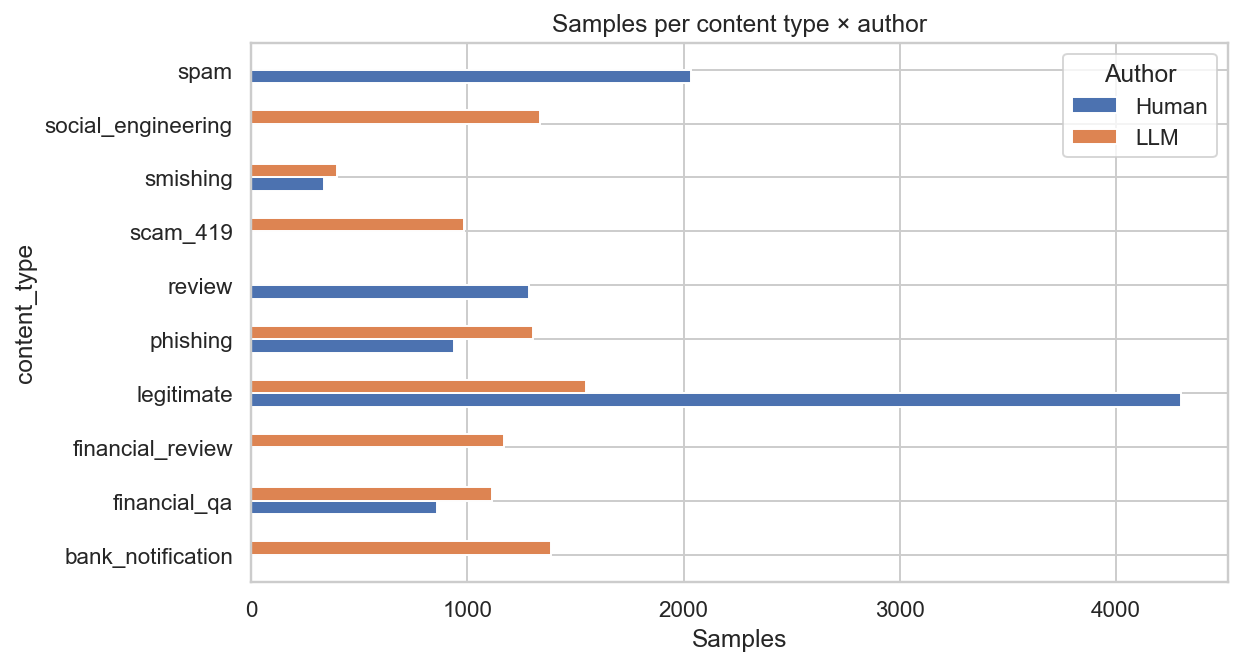

In [18]:
# ── 4a. Samples per content type × label ──
if CT_COL:
    ct_type_label = pd.crosstab(df[CT_COL], df["label_str"], margins=True)
    display(ct_type_label)

    fig, ax = plt.subplots(figsize=(9, 5))
    ct_no_m = ct_type_label.drop(index="All", errors="ignore").drop(columns="All", errors="ignore")
    ct_no_m.plot.barh(ax=ax, color=["#4C72B0", "#DD8452"])
    ax.set_xlabel("Samples")
    ax.set_title("Samples per content type × author")
    ax.legend(title="Author")
    fig.savefig(OUTPUT_DIR / "content_type_label.png")
    plt.show()
else:
    print("Skipped: content-type column not available.")


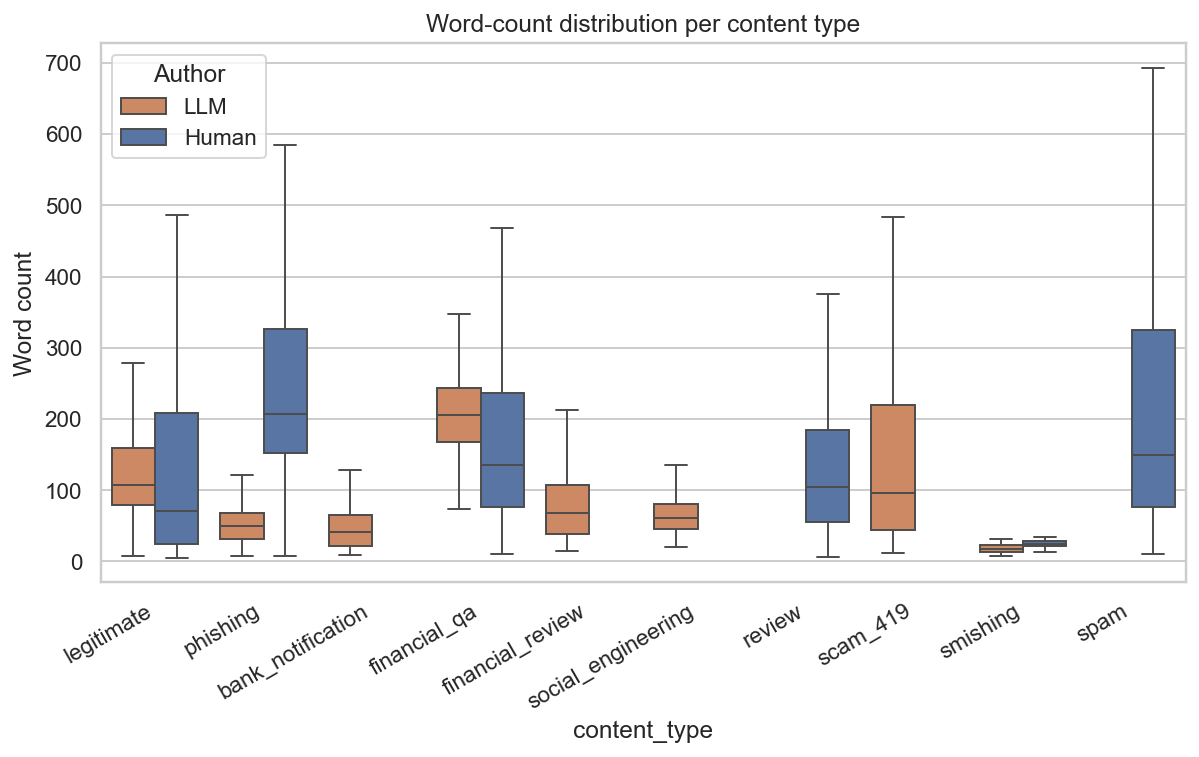

In [19]:
# ── 4b. Word-count by content type × label ──
if CT_COL:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=df, x=CT_COL, y="n_words", hue="label_str",
        showfliers=False, ax=ax,
        palette={"Human": "#4C72B0", "LLM": "#DD8452", "Unknown": "#999999"},
    )
    ax.set_ylabel("Word count")
    ax.set_title("Word-count distribution per content type")
    ax.legend(title="Author")
    plt.xticks(rotation=30, ha="right")
    fig.savefig(OUTPUT_DIR / "content_type_wordcount.png")
    plt.show()
else:
    print("Skipped: content-type column not available.")


## 5 · Per-source / per-model breakdown

In [20]:
# ── Detect source/model column ──
SRC_COL: Optional[str] = None
for candidate in ["origin_model", "dataset_source", "source", "model", "generator", "origin"]:
    if candidate in df.columns:
        SRC_COL = candidate
        break

if SRC_COL:
    print(f"Source/model column found: '{SRC_COL}'")
    display(df[SRC_COL].value_counts(dropna=False))
else:
    print("⚠️ No source/model column found. Section 5 will be limited.")


Source/model column found: 'origin_model'


origin_model
None                                        9757
chatgpt                                     2662
anthropic/claude-haiku-4-5                  2574
gpt-4o-mini                                 2000
mistralai/mistral-small-3.2-24b-instruct    2000
Name: count, dtype: int64

split,train,val,test
origin_model,,,
anthropic/claude-haiku-4-5,0,0,2574
chatgpt,2130,346,186
gpt-4o-mini,1597,267,136
mistralai/mistral-small-3.2-24b-instruct,1602,253,145


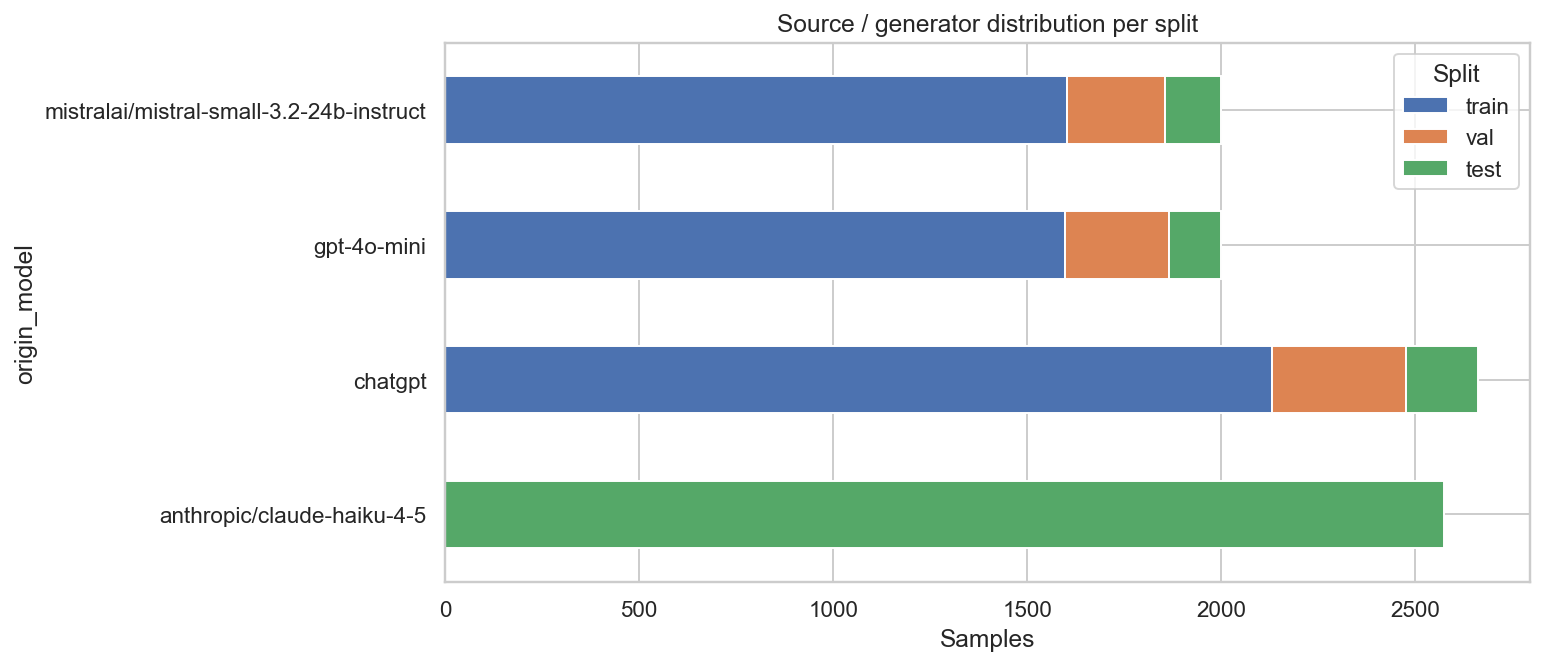

In [21]:
# ── 5a. Samples per source × split ──
if SRC_COL:
    ct_src_split = pd.crosstab(df[SRC_COL], df["split"]).reindex(columns=available_splits)
    display(ct_src_split)

    fig, ax = plt.subplots(figsize=(10, 5))
    ct_src_split.plot.barh(ax=ax, stacked=True)
    ax.set_xlabel("Samples")
    ax.set_title("Source / generator distribution per split")
    ax.legend(title="Split")
    fig.savefig(OUTPUT_DIR / "source_split_distribution.png")
    plt.show()
else:
    print("Skipped: source/model column not available.")


In [22]:
# ── 5b. Verify Claude is held-out (test only) ──
if SRC_COL:
    src_series = df[SRC_COL].astype(str)
    claude_mask = src_series.str.lower().str.contains("claude", na=False)
    if claude_mask.any():
        claude_splits = df.loc[claude_mask, "split"].value_counts()
        print("Claude samples per split:")
        print(claude_splits)
        if set(claude_splits.index) <= {"test"}:
            print("✅ Claude is correctly held-out (test only).")
        else:
            print("❌ WARNING: Claude found in train/val — this violates the experimental design!")
    else:
        print("No Claude entries found in source/model column.")
else:
    print("Skipped: source/model column not available.")


Claude samples per split:
split
test    2574
Name: count, dtype: int64
✅ Claude is correctly held-out (test only).


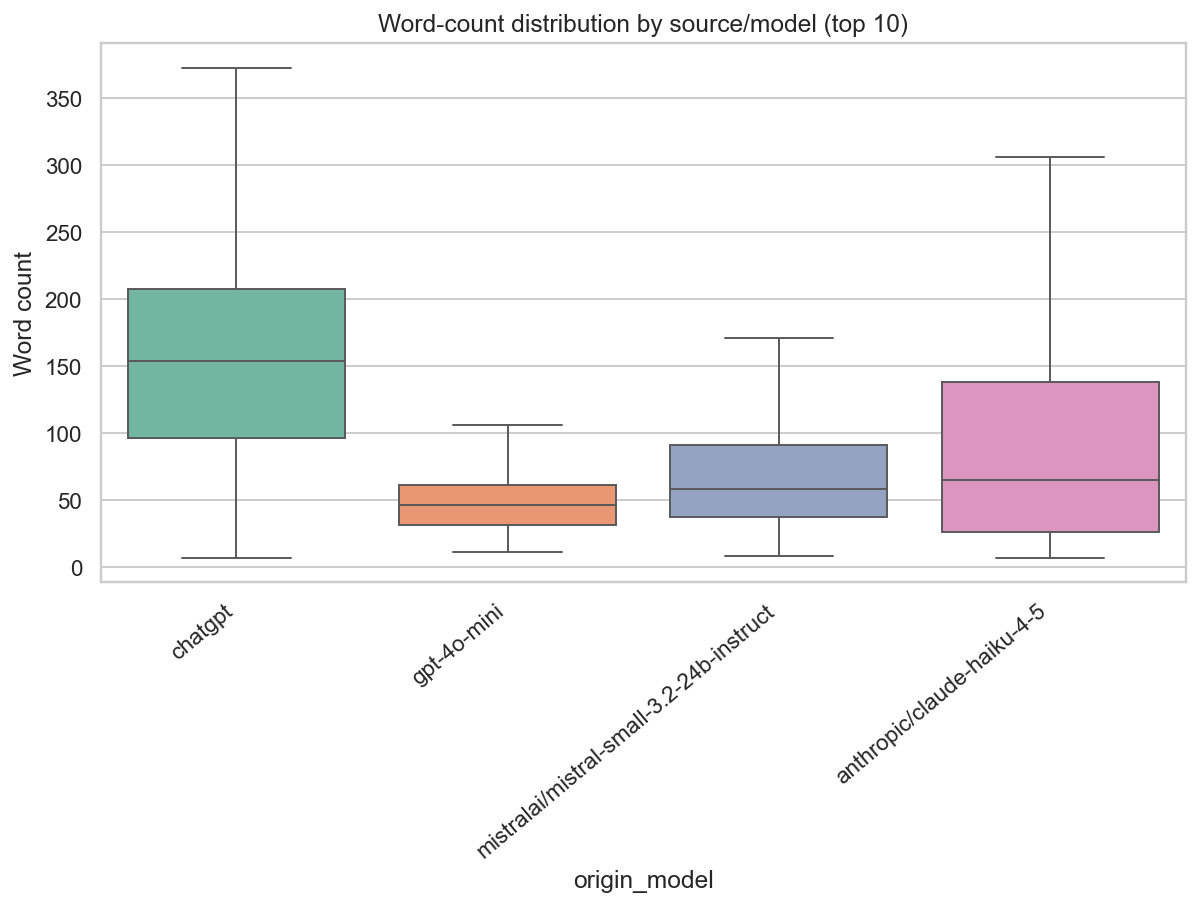

In [23]:
# ── 5c. Word-count by source ──
if SRC_COL:
    top_sources = df[SRC_COL].astype(str).value_counts().head(10).index
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(
        data=df[df[SRC_COL].astype(str).isin(top_sources)],
        x=SRC_COL, y="n_words", showfliers=False, ax=ax,
        palette="Set2",
    )
    ax.set_ylabel("Word count")
    ax.set_title("Word-count distribution by source/model (top 10)")
    plt.xticks(rotation=40, ha="right")
    fig.savefig(OUTPUT_DIR / "source_wordcount.png")
    plt.show()
else:
    print("Skipped: source/model column not available.")


## 6 · Vocabulary & lexical diversity (quick look)

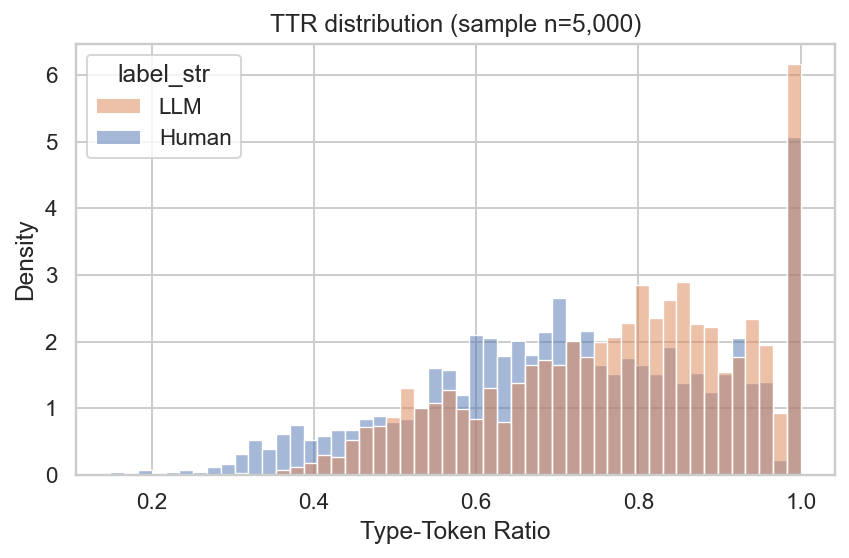


TTR summary by label:


,count,mean,std,min,25%,50%,75%,max
label_str,,,,,,,,
Human,2608.0,0.7147,0.1825,0.1489,0.5945,0.716,0.8592,1.0
LLM,2392.0,0.7761,0.1575,0.3146,0.6680,0.798,0.8976,1.0


In [24]:
# ── 6a. Type-Token Ratio (TTR) per label ──
def ttr(text: str) -> float:
    tokens = text.lower().split()
    if len(tokens) == 0:
        return 0.0
    return len(set(tokens)) / len(tokens)


sample_size = min(5000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).copy()
df_sample["ttr"] = df_sample["text"].apply(ttr)

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=df_sample, x="ttr", hue="label_str", bins=50,
    stat="density", common_norm=False, alpha=0.5, ax=ax,
    palette={"Human": "#4C72B0", "LLM": "#DD8452", "Unknown": "#999999"},
)
ax.set_xlabel("Type-Token Ratio")
ax.set_title(f"TTR distribution (sample n={sample_size:,})")
fig.savefig(OUTPUT_DIR / "ttr_distribution.png")
plt.show()

print("\nTTR summary by label:")
display(df_sample.groupby("label_str")["ttr"].describe().round(4))


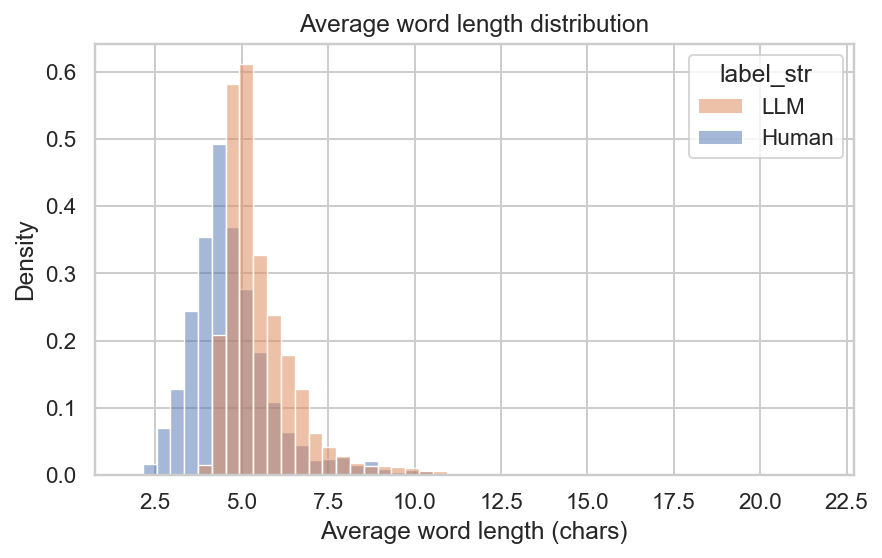

In [25]:
# ── 6b. Average word length ──
def avg_word_len(text: str) -> float:
    tokens = text.split()
    if not tokens:
        return 0.0
    return float(np.mean([len(t) for t in tokens]))


df_sample["avg_wlen"] = df_sample["text"].apply(avg_word_len)

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=df_sample, x="avg_wlen", hue="label_str", bins=50,
    stat="density", common_norm=False, alpha=0.5, ax=ax,
    palette={"Human": "#4C72B0", "LLM": "#DD8452", "Unknown": "#999999"},
)
ax.set_xlabel("Average word length (chars)")
ax.set_title("Average word length distribution")
fig.savefig(OUTPUT_DIR / "avg_word_length.png")
plt.show()


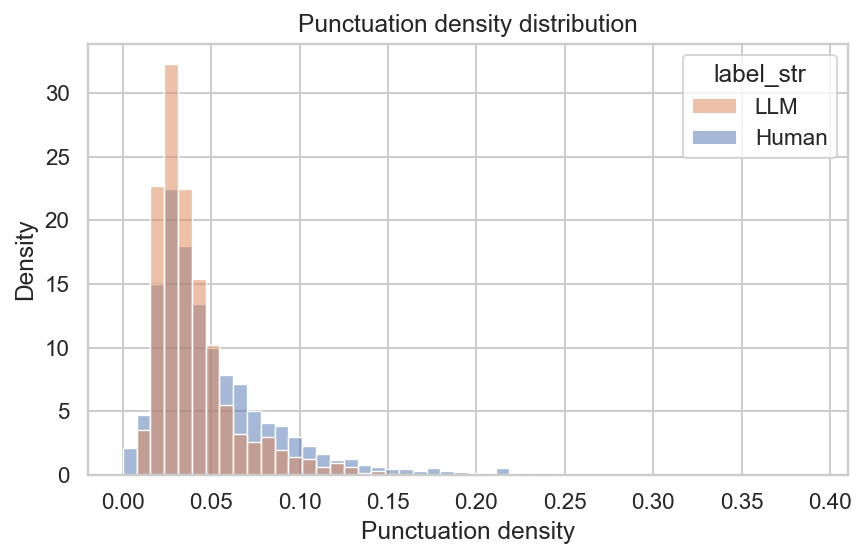

In [26]:
# ── 6c. Punctuation density ──
def punct_density(text: str) -> float:
    if len(text) == 0:
        return 0.0
    return len(re.findall(r"[^\w\s]", text)) / len(text)


df_sample["punct_dens"] = df_sample["text"].apply(punct_density)

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=df_sample, x="punct_dens", hue="label_str", bins=50,
    stat="density", common_norm=False, alpha=0.5, ax=ax,
    palette={"Human": "#4C72B0", "LLM": "#DD8452", "Unknown": "#999999"},
)
ax.set_xlabel("Punctuation density")
ax.set_title("Punctuation density distribution")
fig.savefig(OUTPUT_DIR / "punct_density.png")
plt.show()


## 7 · Save summary tables

In [27]:
# ── 7a. Core stats table ──
summary = (
    df.groupby(["split", "label_str"])
    .agg(
        count=("text", "size"),
        mean_words=("n_words", "mean"),
        median_words=("n_words", "median"),
        std_words=("n_words", "std"),
        mean_chars=("n_chars", "mean"),
        median_chars=("n_chars", "median"),
    )
    .round(1)
)
summary.to_csv(TABLE_DIR / "eda_summary_stats.csv")
print(f"Saved → {TABLE_DIR / 'eda_summary_stats.csv'}")
display(summary)


Saved → /Users/askar/projects/antifraud-deepfake-detection/outputs/tables/eda_summary_stats.csv


count  mean_words  median_words  std_words  mean_chars  \
split label_str                                                           
test  Human       3562       230.5         125.0      570.5      1275.4   
      LLM         3041        93.0          66.0       82.5       618.1   
train Human       5329       193.9         104.0      458.1      1246.1   
      LLM         5329        99.2          72.0       75.1       604.0   
val   Human        866       179.6         109.5      280.8      1175.6   
      LLM          866        96.5          72.0       70.0       588.8   

                 median_chars  
split label_str                
test  Human             683.0  
      LLM               436.0  
train Human             616.0  
      LLM               441.0  
val   Human             611.0  
      LLM               437.0

In [28]:
# ── 7b. Content-type stats ──
if CT_COL:
    ct_summary = (
        df.groupby([CT_COL, "label_str"])
        .agg(
            count=("text", "size"),
            mean_words=("n_words", "mean"),
            median_words=("n_words", "median"),
        )
        .round(1)
    )
    ct_summary.to_csv(TABLE_DIR / "eda_content_type_stats.csv")
    print(f"Saved → {TABLE_DIR / 'eda_content_type_stats.csv'}")
    display(ct_summary)
else:
    print("Skipped: content-type stats were not saved because CT column is unavailable.")


Saved → /Users/askar/projects/antifraud-deepfake-detection/outputs/tables/eda_content_type_stats.csv


count  mean_words  median_words
content_type       label_str                                 
bank_notification  LLM         1388        52.8          41.0
financial_qa       Human        861       181.6         136.0
                   LLM         1114       205.7         205.5
financial_review   LLM         1167        79.5          68.0
legitimate         Human       4304       191.7          71.0
                   LLM         1548       120.4         108.0
phishing           Human        937       257.2         207.0
                   LLM         1302        59.1          50.0
review             Human       1284       137.3         105.0
scam_419           LLM          986       137.6          96.0
smishing           Human        336        24.3          25.0
                   LLM          395        18.3          18.0
social_engineering LLM         1336        70.2          61.0
spam               Human       2035       296.2         149.0

In [29]:
# ── 7c. Source/model stats ──
if SRC_COL:
    src_summary = (
        df.groupby([SRC_COL, "split", "label_str"])
        .agg(
            count=("text", "size"),
            mean_words=("n_words", "mean"),
            median_words=("n_words", "median"),
        )
        .round(1)
        .sort_values("count", ascending=False)
    )
    src_summary.to_csv(TABLE_DIR / "eda_source_stats.csv")
    print(f"Saved → {TABLE_DIR / 'eda_source_stats.csv'}")
    display(src_summary.head(20))
else:
    print("Skipped: source/model stats were not saved because source column is unavailable.")


Saved → /Users/askar/projects/antifraud-deepfake-detection/outputs/tables/eda_source_stats.csv


,,,count,mean_words,median_words
origin_model,split,label_str,,,
anthropic/claude-haiku-4-5,test,LLM,2574,92.0,65.0
chatgpt,train,LLM,2130,156.8,156.0
mistralai/mistral-small-3.2-24b-instruct,train,LLM,1602,74.0,58.0
gpt-4o-mini,train,LLM,1597,47.8,45.0
chatgpt,val,LLM,346,152.4,153.0
gpt-4o-mini,val,LLM,267,47.7,46.0
mistralai/mistral-small-3.2-24b-instruct,val,LLM,253,71.6,59.0
chatgpt,test,LLM,186,154.8,140.5
mistralai/mistral-small-3.2-24b-instruct,test,LLM,145,73.2,61.0


In [30]:
# ── 7d. Cross-ref with dataset_stats.json (if exists) ──
stats_file = DATA_DIR / "dataset_stats.json"
if stats_file.exists():
    with open(stats_file, "r", encoding="utf-8") as f:
        ds_stats = json.load(f)
    print("dataset_stats.json loaded:")
    print(json.dumps(ds_stats, indent=2, ensure_ascii=False)[:3000])
else:
    print(f"File not found: {stats_file}")


dataset_stats.json loaded:
{
  "train": {
    "total": 10658,
    "label_counts": {
      "1": 5329,
      "0": 5329
    },
    "by_source": {
      "hc3_open_qa": 1466,
      "sms_spam_uci": 985,
      "nazario": 674,
      "spamassassin": 1013,
      "generated_gpt4o": 1597,
      "hc3_finance": 1361,
      "generated_mistral": 1602,
      "yelp_hf": 918,
      "enron_spam": 1042
    },
    "by_content_type": {
      "legitimate": 3451,
      "phishing": 1334,
      "bank_notification": 724,
      "financial_qa": 1361,
      "financial_review": 543,
      "social_engineering": 671,
      "review": 918,
      "scam_419": 411,
      "smishing": 424,
      "spam": 821
    },
    "by_model": {
      "chatgpt": 2130,
      "human": 5329,
      "gpt-4o-mini": 1597,
      "mistralai/mistral-small-3.2-24b-instruct": 1602
    }
  },
  "val": {
    "total": 1732,
    "label_counts": {
      "0": 866,
      "1": 866
    },
    "by_source": {
      "spamassassin": 156,
      "hc3_finance": 221,


## 8 · Key observations (for thesis Chapter 2)

**Fill in after running the notebook:**

1. **Class balance:** ...
2. **Length differences:** LLM-generated texts tend to be [longer/shorter] on average.
3. **Content-type imbalance:** ...
4. **TTR differences:** Human texts show [higher/lower] lexical diversity.
5. **Temporal bias caveat:** Human texts (older corpora) vs LLM texts (recent generations) —
   stylistic differences may partly reflect era rather than authorship.
6. **Claude held-out:** Confirmed ✅ / Not confirmed ❌

**Thesis reminder:** interpret very high validation metrics carefully and explicitly discuss
possible temporal / genre / source confounding in the experimental chapter.
